# Supplementary Figure 2: Memory Scalability Detail

Detailed memory analysis across all datasets and tools,
including CELLxGENE large-scale data.

| Panel | Content |
|---|---|
| **S2A** | Memory vs cells scatter (all tools, 55 datasets) |
| **S2B** | Memory savings distribution |
| **S2C** | CELLxGENE memory scaling (10k–1.2M) |

**Data source**: `robustness_benchmark.json`.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json, os, re, subprocess, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('/benchmark/results')
DATA_DIR = Path('/benchmark/data/generated')
FIGURES_DIR_MAIN = Path('/benchmark/figures/main')
FIGURES_DIR_SUPP = Path('/benchmark/figures/supplementary')
TMP_DIR = Path('/tmp/notebook_work')

for d in [RESULTS_DIR, FIGURES_DIR_MAIN, FIGURES_DIR_SUPP, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 10, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

COLORS = {
    'CrossCell': '#025e8d', 'Zellkonverter': '#f58220',
    'anndataR': '#00a69d', 'convert2anndata': '#785ba7',
    'easySCF': '#c75301',
    'success': '#00a69d', 'failed': '#be1818', 'na': '#999999',
}

ALL_TOOLS = ['CrossCell', 'Zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']

def extract_error_reason(stderr_text):
    """Extract a short error reason from R/tool stderr output."""
    if not stderr_text:
        return 'unknown error'
    for line in stderr_text.split('\n'):
        line = line.strip()
        if line.startswith('Error') or 'error' in line.lower():
            return line[:120] + ('...' if len(line) > 120 else '')
    lines = [l.strip() for l in stderr_text.strip().split('\n') if l.strip()]
    if lines:
        return lines[-1][:120]
    return 'unknown error'

FIGURES_DIR = FIGURES_DIR_SUPP
FIG3_FILE = RESULTS_DIR / 'robustness_benchmark.json'
print('✅ Environment setup complete')


✅ Environment setup complete


## 1. Load Memory Data

In [2]:

# Load memory data from robustness_benchmark.json
if FIG3_FILE.exists():
    with open(FIG3_FILE) as f:
        fig3 = json.load(f)
    # Extract memory from all tools with direction
    mem_records = []
    for tool_key, tool_name in [('crosscell', 'CrossCell'), ('zellkonverter', 'Zellkonverter'),
                                 ('anndataR', 'anndataR'), ('convert2anndata', 'convert2anndata'),
                                 ('easySCF', 'easySCF')]:
        for direction in ['rds_to_h5ad', 'h5ad_to_rds']:
            for r in fig3.get(tool_key, {}).get(direction, []):
                if r.get('status') == 'success' and r.get('peak_memory_mb'):
                    mem_records.append({
                        'tool': tool_name, 'dataset': r.get('test_id', ''),
                        'n_cells': r.get('n_cells', 0), 'memory_mb': r['peak_memory_mb'],
                        'direction': direction
                    })
    df_fig3_mem = pd.DataFrame(mem_records)
    print(f'\u2705 Loaded {len(df_fig3_mem)} memory records from robustness_benchmark.json')
else:
    df_fig3_mem = pd.DataFrame()
    print('\u26a0\ufe0f robustness_benchmark.json not found')


✅ Loaded 212 memory records from robustness_benchmark.json


## 2. Supp Fig S2A: Memory vs Cells (All Tools)

Saved supp4a


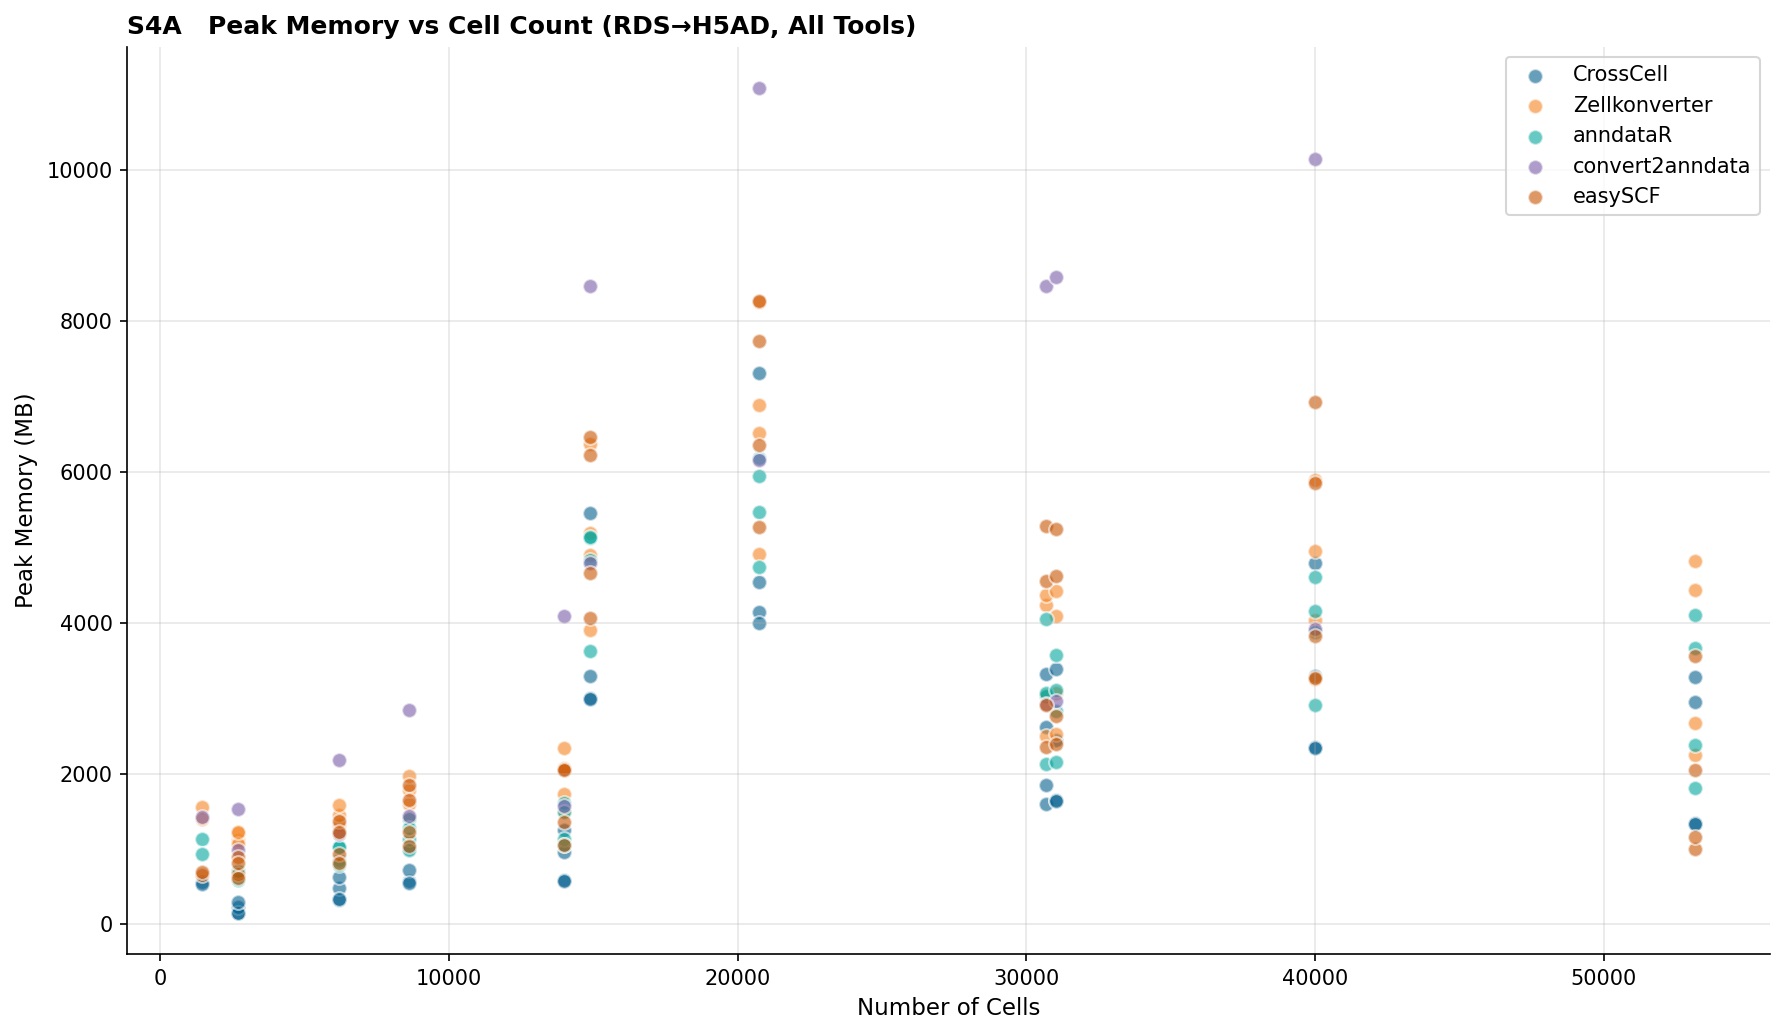

In [3]:

if len(df_fig3_mem) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))
    for tool in ALL_TOOLS:
        df_t = df_fig3_mem[(df_fig3_mem['tool'] == tool) & (df_fig3_mem['direction'] == 'rds_to_h5ad')]
        if len(df_t) > 0:
            ax.scatter(df_t['n_cells'], df_t['memory_mb'], s=50, alpha=0.6,
                      color=COLORS.get(tool, '#999'), label=tool, edgecolor='white')
    ax.set_xlabel('Number of Cells')
    ax.set_ylabel('Peak Memory (MB)')
    ax.set_title('S2A   Peak Memory vs Cell Count (RDS→H5AD, All Tools)', fontweight='bold', loc='left')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'supp2a_memory_scatter.pdf')
    fig.savefig(FIGURES_DIR / 'supp2a_memory_scatter.png')
    print('Saved supp2a')
    plt.show()
else:
    print('No memory data available')


## 3. Supp Fig S2B: Memory Savings Distribution

In [ ]:

if len(df_fig3_mem) > 0:
    cc_mem = df_fig3_mem[(df_fig3_mem['tool'] == 'CrossCell') & (df_fig3_mem['direction'] == 'rds_to_h5ad')]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, tool in zip(axes, ['Zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']):
        t_mem = df_fig3_mem[(df_fig3_mem['tool'] == tool) & (df_fig3_mem['direction'] == 'rds_to_h5ad')]
        merged = cc_mem.merge(t_mem[['dataset', 'memory_mb']], on='dataset',
                              suffixes=('_cc', '_other'), how='inner')
        if len(merged) > 0:
            savings = (1 - merged['memory_mb_cc'] / merged['memory_mb_other']) * 100
            ax.hist(savings, bins=15, color=COLORS.get(tool, '#999'), alpha=0.7, edgecolor='white')
            ax.axvline(x=savings.median(), color='red', linestyle='--')
            ax.set_xlabel('Memory Savings (%)')
            ax.set_title(f'vs {tool}\nMedian: {savings.median():.1f}%', fontsize=9)
        ax.grid(alpha=0.3)
    fig.suptitle('S2B   CrossCell Memory Savings vs Competitors', fontweight='bold', x=0.02, ha='left')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'supp2b_memory_savings.pdf')
    fig.savefig(FIGURES_DIR / 'supp2b_memory_savings.png')
    print('Saved supp2b')
    plt.show()


## 4. Supp Fig S2C: CELLxGENE Memory Scaling

In [ ]:

# CELLxGENE memory data (from Fig 5 datasets)
cellxgene_mem = [
    {'name': 'skin_bcc_10k', 'cells': 9841, 'peak_gb': 0.86, 'sparsity': 93.1},
    {'name': 'tabula_liver_22k', 'cells': 22214, 'peak_gb': 2.03, 'sparsity': 95.4},
    {'name': 'kidney_atacseq_37k', 'cells': 37747, 'peak_gb': 4.5, 'sparsity': 69.4},
    {'name': 'brain_multiome_102k', 'cells': 101924, 'peak_gb': 5.2, 'sparsity': 93.2},
    {'name': 'pancreas_122k', 'cells': 121916, 'peak_gb': 2.48, 'sparsity': 96.0},
    {'name': 'brain_dlpfc_172k', 'cells': 172120, 'peak_gb': 29, 'sparsity': 91.9},
    {'name': 'gut_428k', 'cells': 428469, 'peak_gb': 43, 'sparsity': 94.6},
    {'name': 'heart_486k', 'cells': 486134, 'peak_gb': 35, 'sparsity': 96.1},
    {'name': 'hlca_core_585k', 'cells': 584944, 'peak_gb': 62, 'sparsity': 95.0},
    {'name': 'combat_pbmc_836k', 'cells': 836148, 'peak_gb': 62, 'sparsity': 95.0},
    {'name': 'eqtl_autoimmune_1.2M', 'cells': 1248980, 'peak_gb': 63.4, 'sparsity': 95.0},
]
df_cx = pd.DataFrame(cellxgene_mem)

# Filter out rows with None peak_gb (OOM datasets)
df_cx_valid = df_cx.dropna(subset=['peak_gb']).copy()
df_cx_oom = df_cx[df_cx['peak_gb'].isna()]

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df_cx_valid['cells'], df_cx_valid['peak_gb'], s=80,
                c=df_cx_valid['sparsity'], cmap='RdYlGn', vmin=65, vmax=100,
                edgecolor='white', linewidth=1, zorder=3)
ax.axhline(y=16, color='#785ba7', linestyle='--', linewidth=1.5, alpha=0.7, label='16 GB')
ax.axhline(y=64, color='#be1818', linestyle='--', linewidth=1.5, alpha=0.7, label='64 GB')

# Mark OOM datasets
for _, row in df_cx_oom.iterrows():
    ax.axvline(x=row['cells'], color='#be1818', linestyle=':', linewidth=1, alpha=0.4)
    ax.text(row['cells'], 2, f"{row['name']}\n(OOM)", fontsize=7, ha='center',
            color='#be1818', rotation=90, va='bottom')

for _, row in df_cx_valid.iterrows():
    ax.annotate(row['name'].replace('_', '\n'), (row['cells'], row['peak_gb']),
                fontsize=6, ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

ax.set_xscale('log')
ax.set_xlabel('Number of Cells')
ax.set_ylabel('Peak Memory (GB)')
ax.set_title('S2C   CELLxGENE: Memory Scaling (colored by sparsity)', fontweight='bold', loc='left')
ax.legend(loc='upper left')
plt.colorbar(sc, ax=ax, label='Sparsity (%)', shrink=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'supp2c_cellxgene_memory.pdf')
fig.savefig(FIGURES_DIR / 'supp2c_cellxgene_memory.png')
print('Saved supp2c')
plt.show()


In [ ]:

print('Supplementary Figure 2 complete.')
print('Key finding: Memory scales with nnz, not just cell count.')
print('Sparsity is a critical factor — low sparsity datasets use disproportionate memory.')
